# Case Study
This notebook contains a case study on headway bound analysis on WeGo route 55.  It uses observed dwell and travel distributions as well as the current schedule to generate a baseline and then compares several hypothetical scenarios with holding at a predetermined set of stops.

In [1]:
from copy import deepcopy
from os import path

from plotly import graph_objects
from plotly import express

from analysis.gtfs_utils import load_route_from_gtfs, load_times
from analysis.policies import BolehPolicy, HeadwayDrivenPolicy, ScheduleDrivenPolicy
from analysis.routes import HeadwayResults, RouteConfig, RouteResults, route_factory
from analysis.prob_analysis import simulate
from analysis.wc_analysis import headway_bounds

## Plotting Helpers

In [2]:
def plot_headway(exp_id: str, results: list[RouteResults], ctrl_pts: dict[str, str]) -> None:
    """Plot simulated and analytical headway bounds.

    :param exp_id: Experiment name used used when saving the figure.
    :param results: List of results for each route under consideration.
    :param ctrl_pts: Dictionary mapping control point stop IDs to human readable names.
    """
    fig = graph_objects.Figure()

    for idx, result in enumerate(results):
        fig.add_trace(graph_objects.Scatter(
            line_color=express.colors.qualitative.T10[idx],
            mode='lines',
            showlegend=False,
            x=[s for s in range(len(result.route))],
            y=result.headway.upper_bound,
        ))
        fig.add_trace(graph_objects.Scatter(
            fill='tonexty',
            line_color=express.colors.qualitative.T10[idx],
            mode='lines',
            name='$' + result.name + '$',
            showlegend=True,
            x=[s for s in range(len(result.route))],
            y=result.headway.lower_bound,
        ))

    xticks = ['' for j in range(len(results[0].route))]
    for idx, stop in enumerate(routes[0].route):
        if stop.stop_id in ctrl_pts:
            xticks[idx] = ctrl_pts[stop.stop_id]
            fig.add_vline(
                x=idx,
                line_width=2,
                line_dash="dash",
                line_color="black",
            )

    fig.update_layout(
        # General style
        font_family="Times New Roman, serif",
        
        # Dimensions
        height=360,
        width=850,
        
        # Axes
        xaxis=dict(
            tickangle=45,
            tickmode='array',
            ticktext=xticks,
            tickvals=[i for i in range(len(xticks))],
        ),
        yaxis=dict(
            title='Headway Bounds (min.)',
            title_standoff=0,
        ),

        # Legend
        legend=dict(
            orientation='h',
            x=0.5,
            xanchor='center',
            y=1.15,
            yanchor='top',
        ),
    )

    fig.show()
    fig.write_image(path.join('figures', f'{exp_id}.pdf'))

In [3]:
def run_experiment(exp_id: str, routes: list[RouteConfig], t_max: float, ctrl_pts: dict[str, str]) -> None:
    """Run an experiment.

    :param exp_id: Experiment name.
    :param routes: The routes (including start times) to compare.
    :param t_max: The cutoff time for simulation and analytical analysis.
    :param ctrl_pts: Dictionary mapping control point stop IDs to human readable names.
    """
    results = []
    for route in routes:
        print(f'Working on {route.name}...')
        headway_ub, headway_lb = headway_bounds(route_factory(route.route), route.start_times, t_max)
        # To make the results more clear, we only plot the bounds, not the simulated results or travel time.
        results.append(RouteResults(
            name=route.name,
            route=route.route,
            headway=HeadwayResults(upper_bound=headway_ub, lower_bound=headway_lb, observed=None),
            travel_time=None,
        ))

    plot_headway(exp_id, results, ctrl_pts)

## Load a Route from a GTFS

In [4]:
BASE_ROUTE, START_TIMES = load_route_from_gtfs(route_id=55, service_day='monday')
BASE_ROUTE = load_times(BASE_ROUTE, service_day='Monday', lower_quantile=0.05, upper_quantile=0.95)

## Evaluate Variants of the Route under Different Holding Policies
We create four route variants and compute their headway bounds:
1. Schedule-driven route: use the current stop schedules from the GTFS at the terminal and midpoint to hold buses,
2. Headway-driven holding at MXITHOMP and MXOTHOMP with 30 minutes maximum circuit holding time,
3. Headway-driven holding at MXIGLENG, MXITHOMP, MXIBELL, and MXOTHOMP with 30 minutes maximum circuit holding time,
4. Unbounded headway-driven holding at each stop.

Working on \pi\texttt{SCH}\;\text{(Baseline)}...
Working on \pi\texttt{DYN}\;\text{(All ctrl. pts.)}...
Working on \pi\texttt{DYN}\;\text{(Select ctrl. pts.)}...
Working on \pi\texttt{DYN}\;@\;\text{Every Stop}...


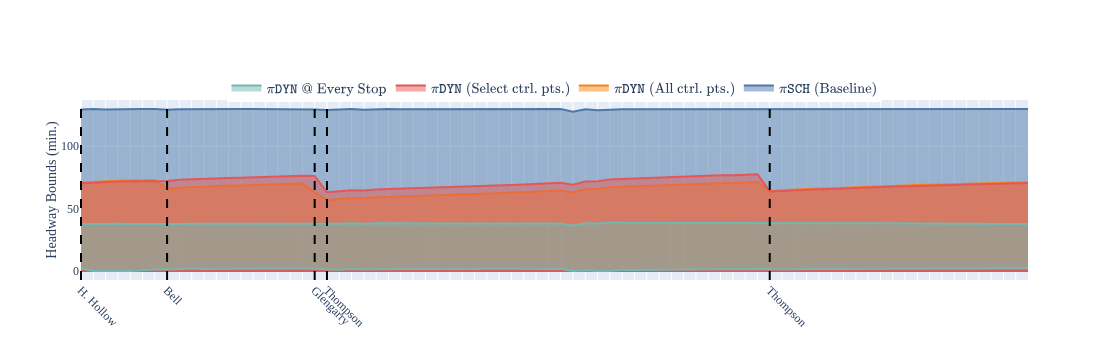

In [5]:
# Schedule-driven route
SCHED_ROUTE= deepcopy(BASE_ROUTE)
for i in range(len(SCHED_ROUTE)):
    if SCHED_ROUTE[i].stop_id in ['HICHICNN', 'MCC4_15']:
        SCHED_ROUTE[i].policy = ScheduleDrivenPolicy
        SCHED_ROUTE[i].policy_args = {'schedule': SCHED_ROUTE[i].scheduled_departures}

# Schedule-driven at terminals, headway-driven at MXIBELL, MXIGLENG, MXITHOMP, and MXOTHOMP
HEADWAY4 = deepcopy(BASE_ROUTE)
for i in range(len(HEADWAY4)):
    if HEADWAY4[i].stop_id in ['MXIBELL', 'MXIGLENG', 'MXITHOMP', 'MXOTHOMP']:
        HEADWAY4[i].policy = HeadwayDrivenPolicy
        HEADWAY4[i].policy_args = {'activation_ratio': 0.75, 'max_holding': 7.5}

# Schedule-driven at terminals, headway-driven at MXITHOMP and MXOTHOMP
HEADWAY2 = deepcopy(BASE_ROUTE)
for i in range(len(HEADWAY2)):
    if HEADWAY2[i].stop_id in [ 'MXITHOMP', 'MXOTHOMP']:
        HEADWAY2[i].policy = HeadwayDrivenPolicy
        HEADWAY2[i].policy_args = {'activation_ratio': 0.75, 'max_holding': 15.0}

# Headway-driven at all stops
HEADWAY_ROUTE= deepcopy(BASE_ROUTE)
for i in range(len(HEADWAY_ROUTE)):
    HEADWAY_ROUTE[i].policy = HeadwayDrivenPolicy
    HEADWAY_ROUTE[i].policy_args = {'activation_ratio': 1, 'max_holding': float('inf')}

routes = [
    RouteConfig(name=r'\pi\texttt{SCH}\;\text{(Baseline)}', route=BASE_ROUTE, start_times=START_TIMES),
    RouteConfig(name=r'\pi\texttt{DYN}\;\text{(All ctrl. pts.)}', route=HEADWAY4, start_times=START_TIMES),
    RouteConfig(name=r'\pi\texttt{DYN}\;\text{(Select ctrl. pts.)}', route=HEADWAY2, start_times=START_TIMES),
    RouteConfig(name=r'\pi\texttt{DYN}\;@\;\text{Every Stop}', route=HEADWAY_ROUTE, start_times=START_TIMES),
]

run_experiment(
    exp_id='route55',
    routes=routes,
    t_max=60 * 24 * 7,
    ctrl_pts=dict(
        HICHICNN='H. Hollow',
        MXIBELL='Bell',
        MXIGLENG='Glengarry',
        MXITHOMP='Thompson',
        MCC4_15='City Ctr.',
        MXOTHOMP='Thompson',
    ),
)